In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("dirty_ecommerce.csv")

In [3]:
df

,order_id,customer_name,email,product_category,product_name,quantity,unit_price,discount,payment_method,order_status,order_date,delivery_date,rating,region
0,ORD-0036,Marco Tan,marco.tan@outlook.com,Home & Living,Rice Cooker,1,899.0,0.20,gcash,delivered,2024-08-28,2024-09-07,3.0,mindanao
1,ORD-0909,Arnold Tolentino,arnold.tolentino@yahoo.com,Food & Grocery,Canned Goods,1,45.0,0.20,Debit Card,delivered,2024-03-01,2024-03-04,2.0,Visayas
2,ORD-0553,Marco Navarro,marco.navarro@outlook.com,Food & Grocery,Rice 5kg,2,250.0,NaN,G-Cash,returned,2024-07-16,NaN,1.0,VISAYAS
3,ORD-0707,SAMMY MACAPAGAL,sammy.macapagal@yahoo.com,Clothing,Jogger Pants,1,799.0,0.05,Debit Card,SHIPPED,2024-01-09,2024-01-13,1.0,Luzon
4,ORD-0315,Dennis Macaraeg,dennis.macaraeg@outlook.com,Electronics,Phone Case,1,199.0,0.15,cod,Shipped,2024-03-23,2024-03-30,NaN,VISAYAS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,ORD-0356,Luz Mendoza,luz.mendoza@outlook.com,Clothing,Running Shoes,5,2500.0,0.10,CreditCard,Delivered,2024-12-20,2024-12-27,5.0,luzon
1026,ORD-0949,juan ramos,juan.ramos@gmail.com,Beauty,Face Wash,1,320.0,0.05,GCash,Delivered,2024-10-07,2024-10-16,2.0,MINDANAO
1027,ORD-0468,Tony Garcia,tony.garcia@yahoo.com,Food & Grocery,Instant Noodles,2,15.0,0.00,Debit Card,Delivered,2024-08-31,2024-09-10,3.0,Mindanao
1028,ORD-0667,Alan Torres,alan.torres@gmail.com,Food & Grocery,Coffee Pack,1,85.0,0.15,Cash on Delivery,Deliverd,2024-08-11,2024-08-21,4.0,visayas


In [4]:
print(df['product_category'].unique())

<StringArray>
['Home & Living', 'Food & Grocery', 'Clothing', 'Electronics', 'Beauty']
Length: 5, dtype: str


In [5]:
# checking values in product category

In [6]:
print(df['payment_method'].unique())

cleanup_map = {
    "gcash": "GCash",
    "Gcash": "GCash",
    "G-Cash": "GCash",
    "cod": "COD",
    "Cash on Delivery": "COD",
    "COD":"COD",
    "debit card": "Debit Card",
    "DebitCard": "Debit Card",
    "CreditCard": "Credit Card",
    "credit card": "Credit Card",
    "Credit card": "Credit Card"
}
df["payment_method"] = df["payment_method"].replace(cleanup_map)

# fixed
print(df['payment_method'].unique())

<StringArray>
[           'gcash',       'Debit Card',           'G-Cash',
              'cod',              'COD',      'Credit Card',
 'Cash on Delivery',       'debit card',        'DebitCard',
      'Credit card',            'Gcash',            'GCash',
       'CreditCard',      'credit card']
Length: 14, dtype: str
<StringArray>
['GCash', 'Debit Card', 'COD', 'Credit Card']
Length: 4, dtype: str


In [7]:
# fixed values in Payment method column

In [8]:
print(df['order_status'].unique())

cleanup_map = {
    "delivered": "Delivered",
    "DELIVERED": "Delivered",
    "Deliverd": "Delivered",
    "returned": "Returned",
    "RETURNED":"Returned",
    "cancelled":"Cancelled",
    "Canceled":"Cancelled",
    "CANCELLED":"Cancelled",
    "SHIPPED":"Shipped",
    "shipped":"Shipped",
}
df['order_status'] = df['order_status'].replace(cleanup_map)
# fixed
print(df['order_status'].unique())

<StringArray>
['delivered',  'returned',   'SHIPPED',   'Shipped',  'Deliverd',  'Returned',
 'DELIVERED', 'Delivered',  'RETURNED',  'Canceled', 'Cancelled', 'CANCELLED',
 'cancelled',   'shipped']
Length: 14, dtype: str
<StringArray>
['Delivered', 'Returned', 'Shipped', 'Cancelled']
Length: 4, dtype: str


In [9]:
# fixed values in order status column

In [10]:
print(df['region'].unique())

df['region'] = df['region'].str.capitalize()
print(df['region'].unique())

<StringArray>
['mindanao',  'Visayas',  'VISAYAS',    'Luzon',    'luzon', 'Mindanao',
 'MINDANAO',    'LUZON',  'visayas']
Length: 9, dtype: str
<StringArray>
['Mindanao', 'Visayas', 'Luzon']
Length: 3, dtype: str


In [11]:
# fixed values in region column

In [12]:
print(df['email'].unique())
# fixed
df['email'] = df['email'].str.lower()
print(df['email'].unique())

<StringArray>
[        'marco.tan@outlook.com',    'arnold.tolentino@yahoo.com',
     'marco.navarro@outlook.com',     'sammy.macapagal@yahoo.com',
   'dennis.macaraeg@outlook.com',       'cynthia.ramos@yahoo.com',
      'felix.santiago@yahoo.com', 'gilbert.evangelista@gmail.com',
            'ana.uy@outlook.com',     'christine.dizon@yahoo.com',
 ...
      'dante.garcia@outlook.com', 'maria.villafuerte@outlook.com',
        'RONALD.LIM@OUTLOOK.COM',  'arnold.macapagal@outlook.com',
    'lena.magsaysay@outlook.com',         'SAMMY.REYES@YAHOO.COM',
         'victor.cruz@yahoo.com',       'luz.mendoza@outlook.com',
          'juan.ramos@gmail.com',   'kevin.villafuerte@yahoo.com']
Length: 932, dtype: str
<StringArray>
[        'marco.tan@outlook.com',    'arnold.tolentino@yahoo.com',
     'marco.navarro@outlook.com',     'sammy.macapagal@yahoo.com',
   'dennis.macaraeg@outlook.com',       'cynthia.ramos@yahoo.com',
      'felix.santiago@yahoo.com', 'gilbert.evangelista@gmail.com',
     

In [13]:
# fixed the format of emails, some of the values are all caps

In [14]:
df['customer_name']
# fixed
df['customer_name'] = df['customer_name'].str.title()
print(df['customer_name'])

0               Marco Tan
1        Arnold Tolentino
2           Marco Navarro
3         Sammy Macapagal
4         Dennis Macaraeg
              ...        
1025          Luz Mendoza
1026           Juan Ramos
1027          Tony Garcia
1028          Alan Torres
1029    Kevin Villafuerte
Name: customer_name, Length: 1030, dtype: str


In [15]:
# fixed the customer name column and made it consistent

In [16]:
df.isnull().sum()

order_id              0
customer_name         0
email                 0
product_category      0
product_name          0
quantity              0
unit_price           34
discount             78
payment_method        0
order_status          0
order_date            0
delivery_date       235
rating              190
region                0
dtype: int64

In [17]:
# check the missing/null values before fixing it

In [18]:
returned_items = df[df['delivery_date'].isnull()]

print(returned_items)

      order_id        customer_name                          email  \
2     ORD-0553        Marco Navarro      marco.navarro@outlook.com   
7     ORD-0012  Gilbert Evangelista  gilbert.evangelista@gmail.com   
11    ORD-0672           Luz Ocampo           luz.ocampo@yahoo.com   
12    ORD-0055   Ronald Villafuerte   ronald.villafuerte@yahoo.com   
15    ORD-0770    Felix Evangelista  felix.evangelista@outlook.com   
...        ...                  ...                            ...   
1002  ORD-0659         Eddie Aquino         eddie.aquino@yahoo.com   
1006  ORD-0806          Arnold Cruz        arnold.cruz@outlook.com   
1012  ORD-0114         Felix Flores         felix.flores@gmail.com   
1017  ORD-0675         Dante Garcia       dante.garcia@outlook.com   
1023  ORD-0556          Sammy Reyes          sammy.reyes@yahoo.com   

     product_category       product_name  quantity  unit_price  discount  \
2      Food & Grocery           Rice 5kg         2       250.0       NaN   
7      

In [19]:
# null values in delivery date column are just cancelled/returned orders

In [20]:
df[df['unit_price'].isnull()][['product_name', 'unit_price']]

,product_name,unit_price
8,Laptop Stand,NaN
24,USB Hub,NaN
74,Bluetooth Speaker,NaN
79,Jogger Pants,NaN
108,Moisturizer,NaN
171,Canned Goods,NaN
176,Wireless Earbuds,NaN
189,Jacket,NaN
205,Electric Fan,NaN
211,Rice Cooker,NaN


In [21]:
# filtered unit price due to null values

In [22]:
df[df['unit_price'].notnull()][['product_name', 'unit_price']]

,product_name,unit_price
0,Rice Cooker,899.0
1,Canned Goods,45.0
2,Rice 5kg,250.0
3,Jogger Pants,799.0
4,Phone Case,199.0
...,...,...
1025,Running Shoes,2500.0
1026,Face Wash,320.0
1027,Instant Noodles,15.0
1028,Coffee Pack,85.0


In [23]:
# found out that some null values in unit price column has the same product name with unit price values in it

In [24]:
df["unit_price"] = df["unit_price"].fillna(df.groupby("product_name")["unit_price"].transform("median"))

In [25]:
# filled the null values in unit price column with the median values of the specific product name

In [26]:
df['discount'] = df['discount'].fillna(0)

In [27]:
# null values in discount means no discount

In [28]:
df.isnull().sum()

order_id              0
customer_name         0
email                 0
product_category      0
product_name          0
quantity              0
unit_price            0
discount              0
payment_method        0
order_status          0
order_date            0
delivery_date       235
rating              190
region                0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(30)

In [30]:
# checking the count of duplicates

In [31]:
df[df.duplicated(keep = False)].sort_values(['order_id'])

,order_id,customer_name,email,product_category,product_name,quantity,unit_price,discount,payment_method,order_status,order_date,delivery_date,rating,region
668,ORD-0003,Homer Tan,homer.tan@outlook.com,Home & Living,Picture Frame,2,220.00,0.05,GCash,Delivered,2024-05-22,2024-06-01,3.0,Visayas
599,ORD-0003,Homer Tan,homer.tan@outlook.com,Home & Living,Picture Frame,2,220.00,0.05,GCash,Delivered,2024-05-22,2024-06-01,3.0,Visayas
579,ORD-0006,Patricia Villafuerte,patricia.villafuerte@outlook.com,Food & Grocery,Rice 5kg,5,10405.41,0.20,COD,Delivered,2024-03-21,2024-03-31,1.0,Mindanao
863,ORD-0006,Patricia Villafuerte,patricia.villafuerte@outlook.com,Food & Grocery,Rice 5kg,5,10405.41,0.20,COD,Delivered,2024-03-21,2024-03-31,1.0,Mindanao
507,ORD-0010,Carla Magsaysay,carla.magsaysay@gmail.com,Home & Living,Bed Sheets,4,650.00,0.00,COD,Delivered,2024-04-07,2024-04-17,2.0,Visayas
450,ORD-0010,Carla Magsaysay,carla.magsaysay@gmail.com,Home & Living,Bed Sheets,4,650.00,0.00,COD,Delivered,2024-04-07,2024-04-17,2.0,Visayas
892,ORD-0012,Gilbert Evangelista,gilbert.evangelista@gmail.com,Electronics,Smart Watch,5,5999.00,0.00,Credit Card,Returned,2024-04-05,NaN,1.0,Mindanao
7,ORD-0012,Gilbert Evangelista,gilbert.evangelista@gmail.com,Electronics,Smart Watch,5,5999.00,0.00,Credit Card,Returned,2024-04-05,NaN,1.0,Mindanao
746,ORD-0015,Rachel Soriano,rachel.soriano@yahoo.com,Home & Living,Rice Cooker,1,899.00,0.00,Credit Card,Delivered,2024-10-09,2024-10-18,NaN,Luzon
238,ORD-0015,Rachel Soriano,rachel.soriano@yahoo.com,Home & Living,Rice Cooker,1,899.00,0.00,Credit Card,Delivered,2024-10-09,2024-10-18,NaN,Luzon


In [32]:
# reviewed the duplicated values first before removing them

In [33]:
df = df.drop_duplicates()
df

,order_id,customer_name,email,product_category,product_name,quantity,unit_price,discount,payment_method,order_status,order_date,delivery_date,rating,region
0,ORD-0036,Marco Tan,marco.tan@outlook.com,Home & Living,Rice Cooker,1,899.0,0.20,GCash,Delivered,2024-08-28,2024-09-07,3.0,Mindanao
1,ORD-0909,Arnold Tolentino,arnold.tolentino@yahoo.com,Food & Grocery,Canned Goods,1,45.0,0.20,Debit Card,Delivered,2024-03-01,2024-03-04,2.0,Visayas
2,ORD-0553,Marco Navarro,marco.navarro@outlook.com,Food & Grocery,Rice 5kg,2,250.0,0.00,GCash,Returned,2024-07-16,NaN,1.0,Visayas
3,ORD-0707,Sammy Macapagal,sammy.macapagal@yahoo.com,Clothing,Jogger Pants,1,799.0,0.05,Debit Card,Shipped,2024-01-09,2024-01-13,1.0,Luzon
4,ORD-0315,Dennis Macaraeg,dennis.macaraeg@outlook.com,Electronics,Phone Case,1,199.0,0.15,COD,Shipped,2024-03-23,2024-03-30,NaN,Visayas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,ORD-0356,Luz Mendoza,luz.mendoza@outlook.com,Clothing,Running Shoes,5,2500.0,0.10,Credit Card,Delivered,2024-12-20,2024-12-27,5.0,Luzon
1026,ORD-0949,Juan Ramos,juan.ramos@gmail.com,Beauty,Face Wash,1,320.0,0.05,GCash,Delivered,2024-10-07,2024-10-16,2.0,Mindanao
1027,ORD-0468,Tony Garcia,tony.garcia@yahoo.com,Food & Grocery,Instant Noodles,2,15.0,0.00,Debit Card,Delivered,2024-08-31,2024-09-10,3.0,Mindanao
1028,ORD-0667,Alan Torres,alan.torres@gmail.com,Food & Grocery,Coffee Pack,1,85.0,0.15,COD,Delivered,2024-08-11,2024-08-21,4.0,Visayas


In [34]:
# removed the duplicated values after reviewing it

In [35]:
df[['quantity', 'unit_price']].describe()

,quantity,unit_price
count,1000.000000,1000.000000
mean,18.542000,1586.453250
std,110.593061,7478.882519
min,1.000000,15.000000
25%,2.000000,199.000000
50%,3.000000,550.000000
75%,4.000000,1200.000000
max,988.000000,221171.140000


In [36]:
# checking for outliers, max quantity, unit price doesn't make sense here

In [37]:
outliers_quantity = df[df['quantity'] > 5]
outliers_quantity.shape

(20, 14)

In [38]:
# put the outliers of quantitry on differenttable just in case it's needed

In [39]:
df = df[df['quantity'] <= 5]
df

,order_id,customer_name,email,product_category,product_name,quantity,unit_price,discount,payment_method,order_status,order_date,delivery_date,rating,region
0,ORD-0036,Marco Tan,marco.tan@outlook.com,Home & Living,Rice Cooker,1,899.0,0.20,GCash,Delivered,2024-08-28,2024-09-07,3.0,Mindanao
1,ORD-0909,Arnold Tolentino,arnold.tolentino@yahoo.com,Food & Grocery,Canned Goods,1,45.0,0.20,Debit Card,Delivered,2024-03-01,2024-03-04,2.0,Visayas
2,ORD-0553,Marco Navarro,marco.navarro@outlook.com,Food & Grocery,Rice 5kg,2,250.0,0.00,GCash,Returned,2024-07-16,NaN,1.0,Visayas
3,ORD-0707,Sammy Macapagal,sammy.macapagal@yahoo.com,Clothing,Jogger Pants,1,799.0,0.05,Debit Card,Shipped,2024-01-09,2024-01-13,1.0,Luzon
4,ORD-0315,Dennis Macaraeg,dennis.macaraeg@outlook.com,Electronics,Phone Case,1,199.0,0.15,COD,Shipped,2024-03-23,2024-03-30,NaN,Visayas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,ORD-0356,Luz Mendoza,luz.mendoza@outlook.com,Clothing,Running Shoes,5,2500.0,0.10,Credit Card,Delivered,2024-12-20,2024-12-27,5.0,Luzon
1026,ORD-0949,Juan Ramos,juan.ramos@gmail.com,Beauty,Face Wash,1,320.0,0.05,GCash,Delivered,2024-10-07,2024-10-16,2.0,Mindanao
1027,ORD-0468,Tony Garcia,tony.garcia@yahoo.com,Food & Grocery,Instant Noodles,2,15.0,0.00,Debit Card,Delivered,2024-08-31,2024-09-10,3.0,Mindanao
1028,ORD-0667,Alan Torres,alan.torres@gmail.com,Food & Grocery,Coffee Pack,1,85.0,0.15,COD,Delivered,2024-08-11,2024-08-21,4.0,Visayas


In [40]:
# saved the fixed table 

In [41]:
outliers_unitPrice = df[df['unit_price'] > 8500]
outliers_unitPrice.shape

(12, 14)

In [42]:
# put the outliers of unit price on different table as well

In [43]:
df = df[df['unit_price'] <= 8500]
df

,order_id,customer_name,email,product_category,product_name,quantity,unit_price,discount,payment_method,order_status,order_date,delivery_date,rating,region
0,ORD-0036,Marco Tan,marco.tan@outlook.com,Home & Living,Rice Cooker,1,899.0,0.20,GCash,Delivered,2024-08-28,2024-09-07,3.0,Mindanao
1,ORD-0909,Arnold Tolentino,arnold.tolentino@yahoo.com,Food & Grocery,Canned Goods,1,45.0,0.20,Debit Card,Delivered,2024-03-01,2024-03-04,2.0,Visayas
2,ORD-0553,Marco Navarro,marco.navarro@outlook.com,Food & Grocery,Rice 5kg,2,250.0,0.00,GCash,Returned,2024-07-16,NaN,1.0,Visayas
3,ORD-0707,Sammy Macapagal,sammy.macapagal@yahoo.com,Clothing,Jogger Pants,1,799.0,0.05,Debit Card,Shipped,2024-01-09,2024-01-13,1.0,Luzon
4,ORD-0315,Dennis Macaraeg,dennis.macaraeg@outlook.com,Electronics,Phone Case,1,199.0,0.15,COD,Shipped,2024-03-23,2024-03-30,NaN,Visayas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,ORD-0356,Luz Mendoza,luz.mendoza@outlook.com,Clothing,Running Shoes,5,2500.0,0.10,Credit Card,Delivered,2024-12-20,2024-12-27,5.0,Luzon
1026,ORD-0949,Juan Ramos,juan.ramos@gmail.com,Beauty,Face Wash,1,320.0,0.05,GCash,Delivered,2024-10-07,2024-10-16,2.0,Mindanao
1027,ORD-0468,Tony Garcia,tony.garcia@yahoo.com,Food & Grocery,Instant Noodles,2,15.0,0.00,Debit Card,Delivered,2024-08-31,2024-09-10,3.0,Mindanao
1028,ORD-0667,Alan Torres,alan.torres@gmail.com,Food & Grocery,Coffee Pack,1,85.0,0.15,COD,Delivered,2024-08-11,2024-08-21,4.0,Visayas


In [44]:
# saved the fixed table

In [45]:
df['total_price'] = df['quantity'] * df['unit_price'] * (1 - df["discount"])

In [46]:
# Added total price after discounts

In [47]:
print(df.columns.tolist())

['order_id', 'customer_name', 'email', 'product_category', 'product_name', 'quantity', 'unit_price', 'discount', 'payment_method', 'order_status', 'order_date', 'delivery_date', 'rating', 'region', 'total_price']


In [48]:
new_order = ['order_id', 'customer_name', 'email', 'product_category', 'product_name', 'quantity', 'unit_price', 'discount', 'total_price', 'payment_method', 'order_status', 'order_date', 'delivery_date', 'rating', 'region']
df =df[new_order]

In [49]:
# put the new colunm next to unit price and discount

In [50]:
df

,order_id,customer_name,email,product_category,product_name,quantity,unit_price,discount,total_price,payment_method,order_status,order_date,delivery_date,rating,region
0,ORD-0036,Marco Tan,marco.tan@outlook.com,Home & Living,Rice Cooker,1,899.0,0.20,719.20,GCash,Delivered,2024-08-28,2024-09-07,3.0,Mindanao
1,ORD-0909,Arnold Tolentino,arnold.tolentino@yahoo.com,Food & Grocery,Canned Goods,1,45.0,0.20,36.00,Debit Card,Delivered,2024-03-01,2024-03-04,2.0,Visayas
2,ORD-0553,Marco Navarro,marco.navarro@outlook.com,Food & Grocery,Rice 5kg,2,250.0,0.00,500.00,GCash,Returned,2024-07-16,NaN,1.0,Visayas
3,ORD-0707,Sammy Macapagal,sammy.macapagal@yahoo.com,Clothing,Jogger Pants,1,799.0,0.05,759.05,Debit Card,Shipped,2024-01-09,2024-01-13,1.0,Luzon
4,ORD-0315,Dennis Macaraeg,dennis.macaraeg@outlook.com,Electronics,Phone Case,1,199.0,0.15,169.15,COD,Shipped,2024-03-23,2024-03-30,NaN,Visayas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,ORD-0356,Luz Mendoza,luz.mendoza@outlook.com,Clothing,Running Shoes,5,2500.0,0.10,11250.00,Credit Card,Delivered,2024-12-20,2024-12-27,5.0,Luzon
1026,ORD-0949,Juan Ramos,juan.ramos@gmail.com,Beauty,Face Wash,1,320.0,0.05,304.00,GCash,Delivered,2024-10-07,2024-10-16,2.0,Mindanao
1027,ORD-0468,Tony Garcia,tony.garcia@yahoo.com,Food & Grocery,Instant Noodles,2,15.0,0.00,30.00,Debit Card,Delivered,2024-08-31,2024-09-10,3.0,Mindanao
1028,ORD-0667,Alan Torres,alan.torres@gmail.com,Food & Grocery,Coffee Pack,1,85.0,0.15,72.25,COD,Delivered,2024-08-11,2024-08-21,4.0,Visayas


In [51]:
# final cleaned data

In [52]:
df[df['order_status'] == 'Delivered'].value_counts(['region']).sort_values(ascending = False)

region  
Mindanao    227
Visayas     221
Luzon       192
Name: count, dtype: int64

In [53]:
# what region has the most orders that are completed

In [54]:
df.groupby(['product_category'])['total_price'].sum().sort_values(ascending = False)

product_category
Home & Living     1216816.400
Electronics        854598.500
Clothing           633908.350
Beauty             257260.110
Food & Grocery      67641.637
Name: total_price, dtype: float64

In [55]:
# revenue per product category

In [56]:
df.groupby(['payment_method'])['payment_method'].count().sort_values(ascending = False)
# df["payment_method"].value_counts()

payment_method
Debit Card     256
GCash          241
Credit Card    236
COD            235
Name: payment_method, dtype: int64

In [57]:
# What Mode of Payment are used frequently

In [58]:
df['order_status'].value_counts()

order_status
Delivered    640
Cancelled    120
Shipped      105
Returned     103
Name: count, dtype: int64

In [59]:
# Order status breakdown

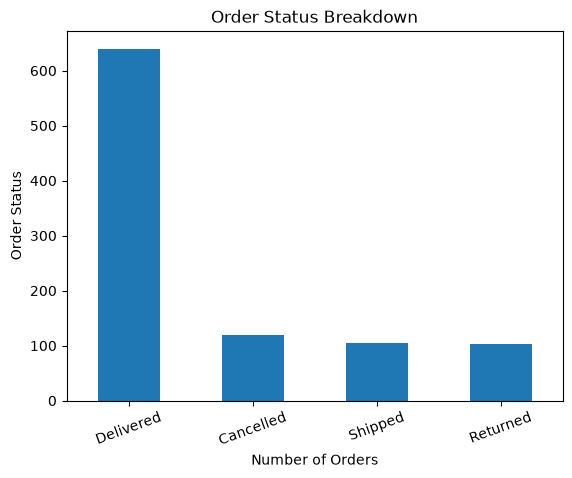

In [60]:
data = df["order_status"].value_counts()
data.plot(kind="bar")
plt.title("Order Status Breakdown")
plt.xlabel("Number of Orders")
plt.ylabel("Order Status")
plt.xticks(rotation=20)
plt.show()

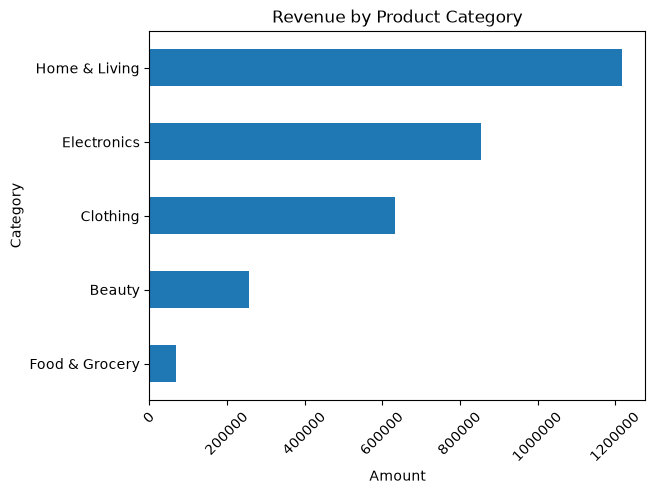

In [61]:
data = df.groupby(['product_category'])['total_price'].sum().sort_values(ascending = True)
data.plot(kind = 'barh')
plt.title('Revenue by Product Category')
plt.xlabel('Amount')
plt.ylabel('Category')
plt.ticklabel_format(style= 'plain', axis= 'x')
plt.xticks(rotation = 45)
plt.show()

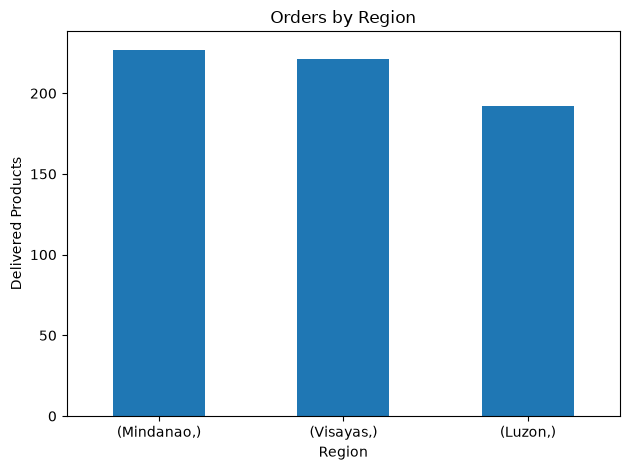

In [62]:
data = df[df['order_status'] == 'Delivered'].value_counts(['region']).sort_values(ascending = False)
data.plot(kind ='bar')
plt.title('Orders by Region')
plt.xlabel('Region')
plt.ylabel('Delivered Products')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()


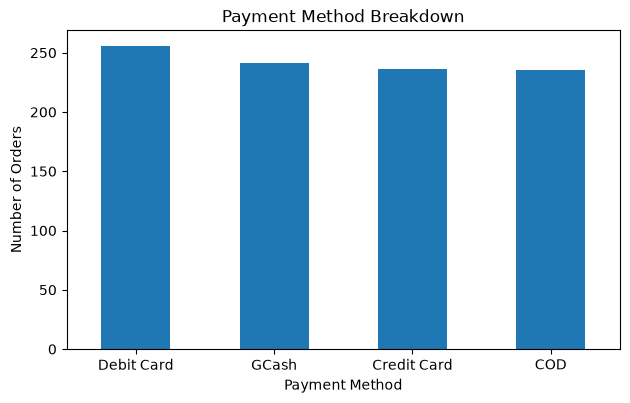

In [63]:
data = df["payment_method"].value_counts()
data.plot(kind = 'bar')
plt.title('Payment Method Breakdown')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.xticks(rotation = 0)
plt.show()
